In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('/content/Plant_1_Generation_Data.csv.zip')

In [4]:
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [5]:
df.isnull().sum()

,0
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0


In [6]:
df.drop_duplicates()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...,...,...
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0


In [10]:
df['DATE_TIME']= pd.to_datetime(df['DATE_TIME'], format='%d-%m-%Y %H:%M')

In [11]:
df['Hour'] = df['DATE_TIME'].dt.hour

df['Day'] = df['DATE_TIME'].dt.day

df['Month'] = df['DATE_TIME'].dt.month

In [13]:
corr = df.corr(numeric_only=True)

print(corr['AC_POWER'])

PLANT_ID            NaN
DC_POWER       0.999996
AC_POWER       1.000000
DAILY_YIELD    0.082234
TOTAL_YIELD    0.003804
Hour           0.024101
Day            0.032902
Month         -0.037464
Name: AC_POWER, dtype: float64


<Axes: >

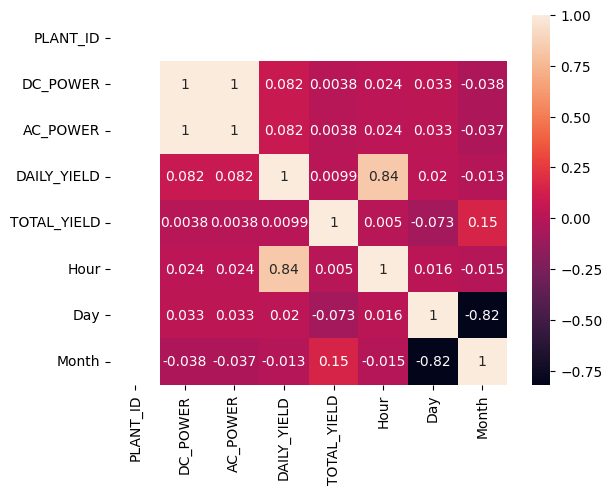

In [14]:
import seaborn as sns
sns.heatmap(corr,annot=True)

In [15]:
X = df[
    [
        'DC_POWER',
        'DAILY_YIELD',
        'TOTAL_YIELD',
        'Hour'
    ]
]

y = df['AC_POWER']

In [18]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
X_train

,DC_POWER,DAILY_YIELD,TOTAL_YIELD,Hour
28764,0.00000,8210.000000,7102189.000,22
11405,0.00000,8982.000000,7248524.000,18
12052,11223.57143,2425.285714,7212623.286,10
51899,0.00000,8309.000000,7233863.000,23
13363,0.00000,0.000000,6233247.000,2
...,...,...,...,...
37194,0.00000,7350.000000,7307650.000,22
6265,0.00000,0.000000,6204353.000,3
54886,4509.50000,707.375000,7380486.375,9
860,6008.37500,1161.250000,6260720.250,10


In [21]:
X_test

,DC_POWER,DAILY_YIELD,TOTAL_YIELD,Hour
53615,0.000000,6645.000000,7240508.000,19
25461,0.000000,0.000000,7206549.000,0
5246,7333.875000,6442.000000,7036055.000,15
33499,0.000000,0.000000,6308232.000,4
4699,7665.500000,961.375000,7021701.375,9
...,...,...,...,...
5784,0.000000,7606.000000,7179627.000,21
40305,10364.714290,1668.285714,7156781.286,10
52613,4396.285714,326.428571,7403142.429,7
18514,3352.000000,6880.625000,6327283.625,15


In [22]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [24]:
pred = model.predict(X_test)

In [25]:
pred

array([2.55945545e-01, 2.46313471e-01, 7.16804443e+02, ...,
       4.29837358e+02, 3.27749702e+02, 2.51306709e-01])

<Axes: xlabel='AC_POWER', ylabel='Count'>

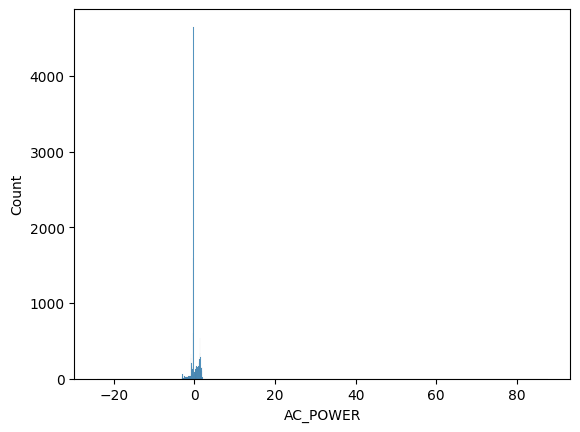

In [26]:
sns.histplot(y_test-pred)

In [27]:
mean_absolute_error=mean_absolute_error(y_test,pred)
mean_absolute_error

0.7145121142984302

In [28]:
r2_score=r2_score(y_test,pred)
r2_score


0.9999861792430806

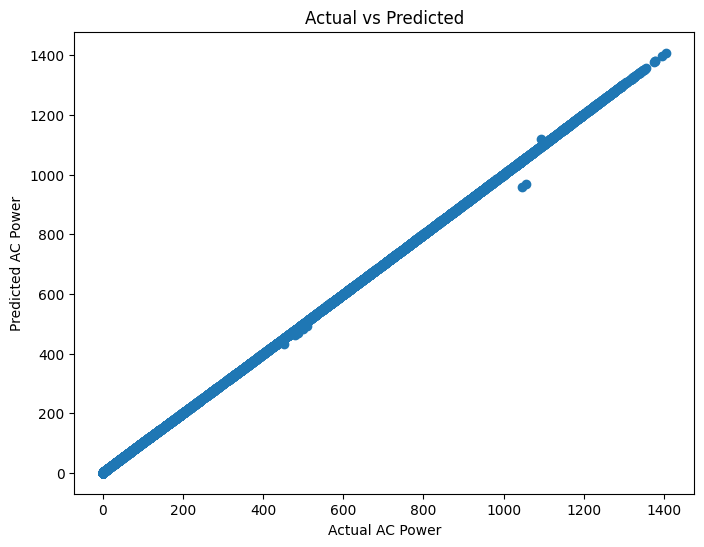

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred
)

plt.xlabel("Actual AC Power")

plt.ylabel("Predicted AC Power")

plt.title("Actual vs Predicted")

plt.show()

Why did you choose Linear Regression?

Because:

AC_POWER

is a continuous numerical variable.

Examples:

1200.5
1400.8
3000.4

Linear Regression predicts continuous values.